# Customer Intelligence & Churn Prediction Platform

## Exploratory Data Analysis (EDA)

### Objective
Analyze customer behavior and identify the major factors influencing customer churn.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("../data/telco_cleaned.csv")

# 1. Churn Distribution Analysis

Understanding overall churn distribution.

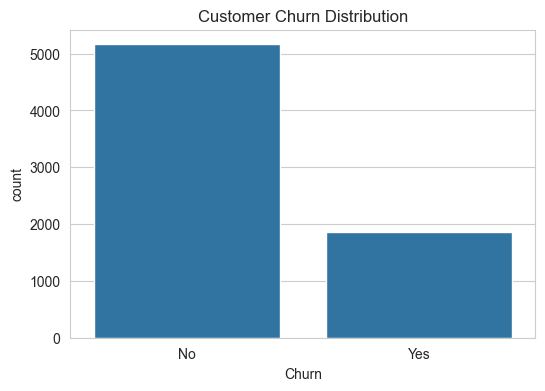

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.show()

In [7]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

### Business Insight

Approximately 26.6% of customers churned while 73.4% remained.

Customer churn represents a significant business challenge and requires targeted retention strategies.

# 2. Tenure vs Churn

Analyzing whether customer loyalty duration influences churn.

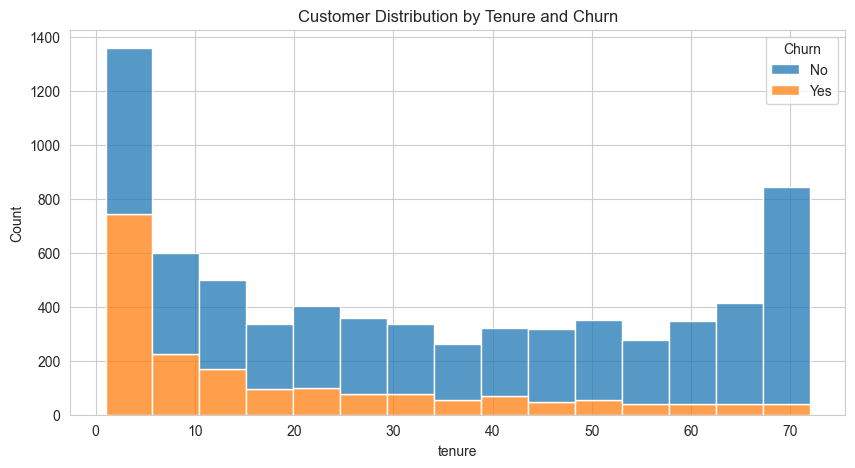

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    multiple="stack"
)

plt.title("Customer Distribution by Tenure and Churn")

plt.show()

### Business Insight

Customers with lower tenure exhibit substantially higher churn rates.

Long-term customers demonstrate stronger loyalty and lower churn probability.

# 3. Monthly Charges vs Churn

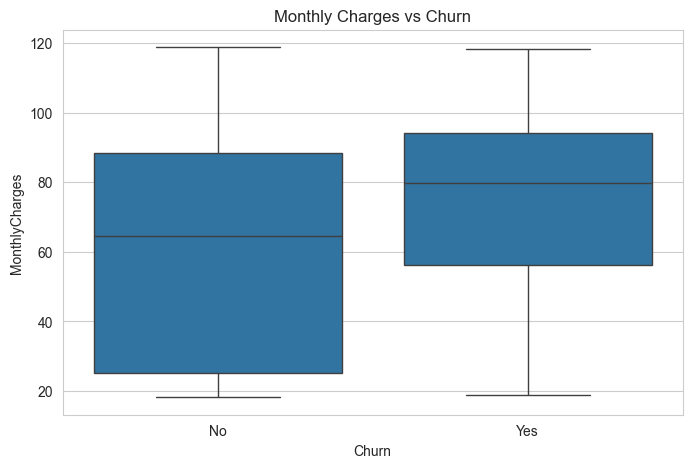

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

### Business Insight

Customers with higher monthly charges are more likely to churn.

Pricing pressure may contribute significantly to customer dissatisfaction and attrition.

# 4. Contract Type vs Churn

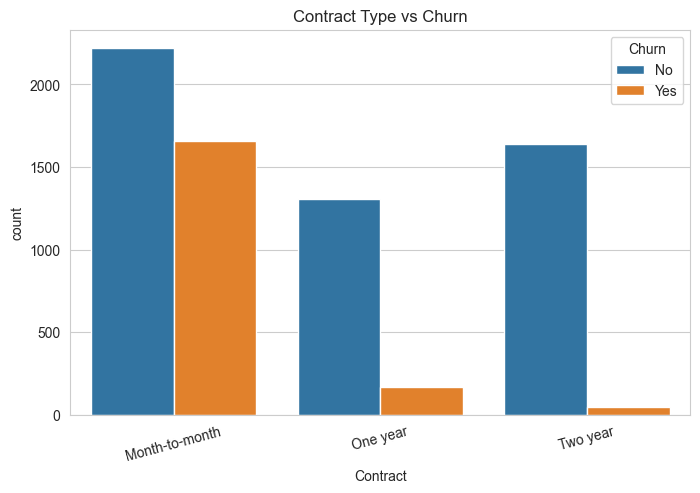

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

### Business Insight

Month-to-month customers show substantially higher churn rates compared to customers on annual contracts.

Long-term contracts promote customer retention and stability.

# 5. Internet Service vs Churn

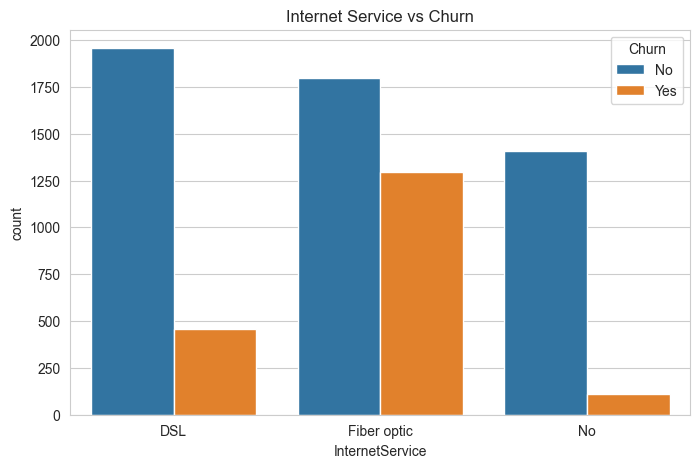

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

### Business Insight

Fiber optic customers exhibit relatively higher churn behavior compared to DSL customers.

This may indicate pricing concerns or service quality expectations.

# 6. Correlation Analysis

In [19]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_corr = df.copy()

# Remove customerID
df_corr = df_corr.drop("customerID", axis=1)

for col in df_corr.columns:
    if not pd.api.types.is_numeric_dtype(df_corr[col]):
        df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

In [20]:
df_corr.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

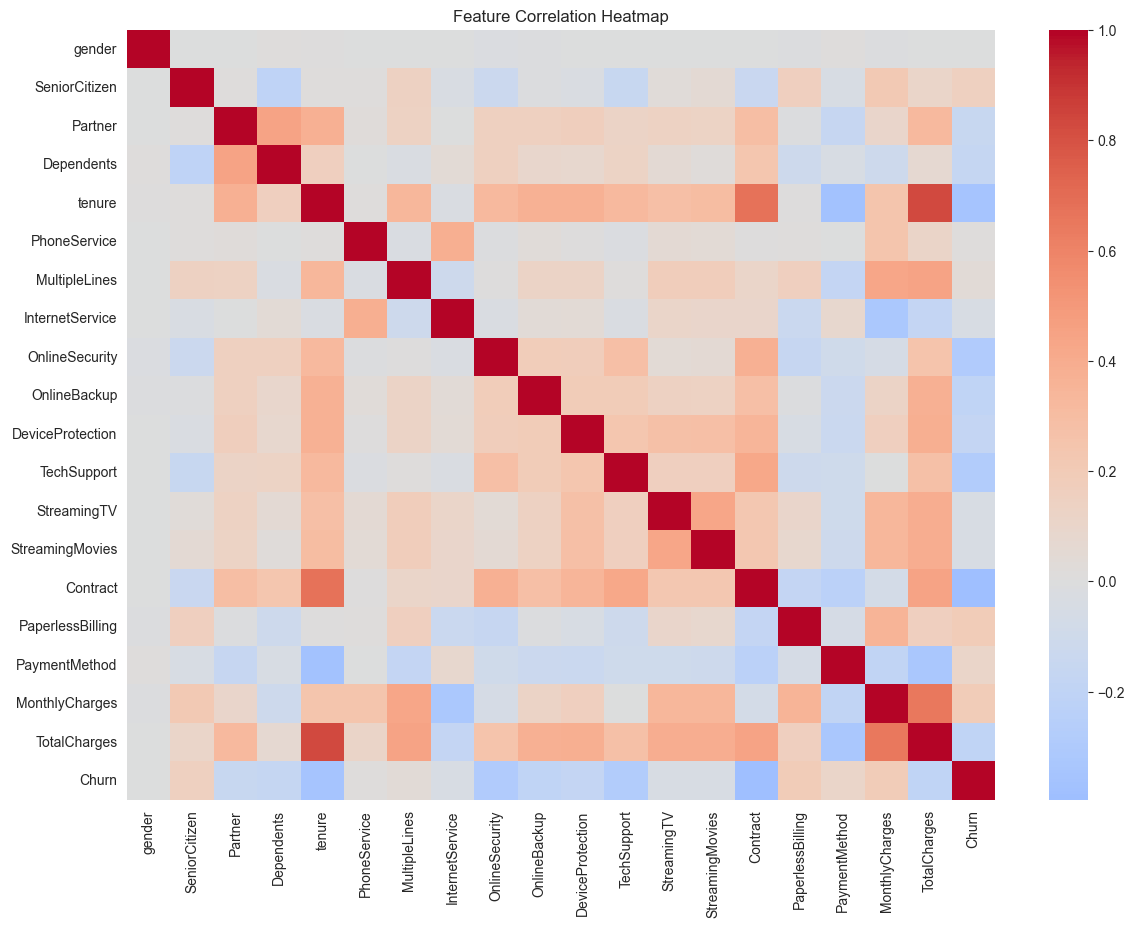

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_corr.corr(),
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()


In [22]:
churn_corr = df_corr.corr()["Churn"].sort_values(
    ascending=False
)

churn_corr

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

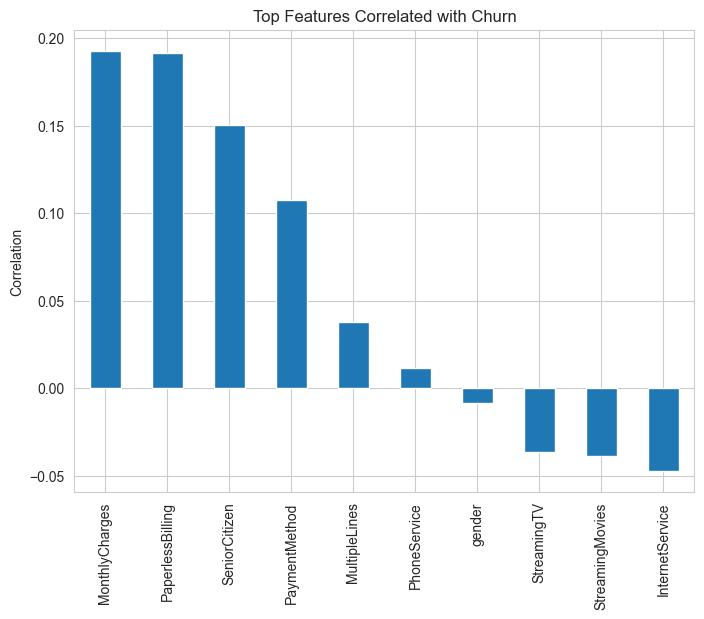

In [23]:
plt.figure(figsize=(8,6))

churn_corr.drop("Churn").head(10).plot(kind="bar")

plt.title("Top Features Correlated with Churn")

plt.ylabel("Correlation")

plt.show()

## Key Correlation Findings

Positive Churn Drivers:
- Month-to-month contracts
- Higher monthly charges
- Fiber optic internet service

Negative Churn Drivers:
- Longer tenure
- Higher total charges
- Long-term contracts

These findings align with earlier visual analysis and provide evidence-based business insights.

# EDA Conclusion

Major churn drivers identified:

1. Low customer tenure
2. High monthly charges
3. Month-to-month contracts
4. Fiber optic internet service

Business Recommendations:

- Focus retention campaigns on newly acquired customers.
- Encourage migration to annual or two-year contracts.
- Monitor customers with high monthly charges.
- Improve retention initiatives for fiber optic subscribers.

These insights will guide feature engineering and predictive modeling in the next stage.